# Solutions · 15 · Boundary-value problems: heat transfer in a fin

Worked solutions to the exercises of [notebook 15](../notebooks/15_boundary_value_problems.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import bvp, linalg
import time
D = 0.005; L = 0.05; Ac = np.pi*D**2/4

## Exercise 1

Solve the radiating fin by shooting instead (tip condition $T'(L) = 0$). The ODE is nonlinear, so the
   secant iteration no longer converges in one step. Compare the heat rates.

In [2]:
ks, hs, eps, sigma = 40.0, 10.0, 0.9, 5.670374419e-8
Tb2, Tinf2 = 673.15, 293.15
m2sq, rad = 4*hs/(ks*D), eps*sigma*4/(ks*D)
f = lambda x, T, dT: m2sq*(T - Tinf2) + rad*(T**4 - Tinf2**4)
xs, Ts, dTs, s = bvp.shooting(f, 0, L, Tb2, ("robin", 1.0, 0.0, 0.0), slopes=(-8000.0, -4000.0), n=400)
print(f"shooting: T'(0) = {s:.2f} K/m, heat rate {-ks*Ac*s:.3f} W, tip temperature {Ts[-1] - 273.15:.1f} °C")
print(f"tip slope T'(L) = {dTs[-1]:.2e} K/m (should be 0)")
print("finite differences + Newton (notebook 15): 6.01 W")

shooting: T'(0) = -7659.20 K/m, heat rate 6.016 W, tip temperature 240.1 °C
tip slope T'(L) = 4.55e-12 K/m (should be 0)
finite differences + Newton (notebook 15): 6.01 W


Shooting gives the same heat rate as the finite-difference/Newton solution of the notebook (the small
remaining difference is the finite-difference discretisation error). For a nonlinear ODE the tip miss is
no longer a straight-line function of the initial slope, so the secant method needs several iterations
instead of one - it still converges quickly because the miss is a smooth function of the slope.

## Exercise 2

**Beam deflection.** A simply supported beam under uniform load satisfies $EI\,v'' = -M(x)$ with
   the sagging bending moment $M(x) = wx(L - x)/2$, $v(0) = v(L) = 0$ and $v$ the deflection measured
   downwards. Solve it with
   `bvp.finite_difference` and compare the midspan deflection with $5wL^4/(384EI)$ (notebook 13).

In [3]:
E, I = 200e9, 0.05*0.10**3/12
w, Lb = 2000.0, 4.0
EI = E*I
exact_mid = 5*w*Lb**4/(384*EI)
for n in (10, 20, 40, 80):
    # v'' = -M(x)/EI  with  M = w x (L - x) / 2   (v downwards, sagging moment positive)
    xb, vb = bvp.finite_difference(lambda x: 0*x, lambda x: 0*x, lambda x: -w*x*(Lb - x)/(2*EI),
                                   0, Lb, n, ("dirichlet", 0.0), ("dirichlet", 0.0))
    print(f"n = {n:>2}: midspan deflection {vb[n//2]*1000:.5f} mm (exact {exact_mid*1000:.5f} mm)")

n = 10: midspan deflection 8.06400 mm (exact 8.00000 mm)
n = 20: midspan deflection 8.01600 mm (exact 8.00000 mm)
n = 40: midspan deflection 8.00400 mm (exact 8.00000 mm)
n = 80: midspan deflection 8.00100 mm (exact 8.00000 mm)


The midspan deflection converges to the handbook value $5wL^4/(384EI)$ with errors 0.064, 0.016, 0.004 and
0.001 mm: each halving of the spacing divides the error by exactly 4, the signature of second-order
accuracy. It is *exactly* 4 here because the exact deflection is a quartic, whose fourth derivative - the
quantity in the leading error term $h^2 v''''/12$ - is constant. Ten intervals already give 0.8 % accuracy.

## Exercise 3

Fin **efficiency** is the actual heat rate divided by the rate if the whole fin were at $T_b$. Plot it
   against fin length for the aluminium fin. Beyond which length does extra length hardly help?

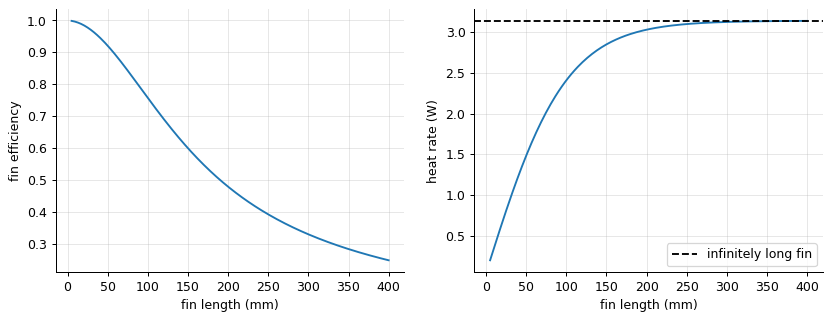

50 mm fin: efficiency 0.92; 95 % of the maximum heat rate at L = 184 mm (mL = 1.84)


In [4]:
k, h, Tb, Tinf = 200.0, 25.0, 100.0, 20.0
m = np.sqrt(4*h/(k*D)); Bi = h/(m*k)
lengths = np.linspace(0.005, 0.40, 200)
q = k*Ac*m*(Tb - Tinf)*(np.sinh(m*lengths) + Bi*np.cosh(m*lengths))/(np.cosh(m*lengths) + Bi*np.sinh(m*lengths))
area = np.pi*D*lengths + Ac
eff = q/(h*area*(Tb - Tinf))
q_inf = np.sqrt(h*np.pi*D*k*Ac)*(Tb - Tinf)            # infinitely long fin
L95 = lengths[np.argmax(q >= 0.95*q_inf)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(lengths*1000, eff); a1.set(xlabel="fin length (mm)", ylabel="fin efficiency")
a2.plot(lengths*1000, q); a2.axhline(q_inf, color="k", ls="--", label="infinitely long fin")
a2.set(xlabel="fin length (mm)", ylabel="heat rate (W)"); a2.legend(); plt.show()
print(f"50 mm fin: efficiency {np.interp(0.05, lengths, eff):.2f}; 95 % of the maximum heat rate at L = {L95*1000:.0f} mm (mL = {m*L95:.2f})")

Efficiency falls steadily with length, because the far parts of a long fin are barely warmer than the air.
The heat rate levels off: beyond $mL \approx 1.8$ (here about 180 mm) the fin already delivers 95 % of what
an infinitely long fin could, so extra length adds material, weight and cost for almost nothing. The
50 mm fin, at $mL$ = 0.5, is short and efficient.

## Exercise 4

**Implement it yourself:** write a finite-difference solver for $y'' = r(x)$ with Dirichlet ends that builds the full (dense) matrix and uses `np.linalg.solve`. Compare its time with `bvp.finite_difference` (Thomas algorithm) for n = 500, 1000 and 2000.

In [5]:
def fd_dense(r, a, b, n, ya, yb):
    x = np.linspace(a, b, n + 1); hx = x[1] - x[0]
    A = np.zeros((n + 1, n + 1)); rhs = r(x) * hx**2
    A[0, 0] = A[-1, -1] = 1.0; rhs[0], rhs[-1] = ya, yb
    for i in range(1, n):
        A[i, i-1], A[i, i], A[i, i+1] = 1.0, -2.0, 1.0
    return x, np.linalg.solve(A, rhs)

r = lambda x: -np.pi**2*np.sin(np.pi*x)                 # exact y = sin(pi x)
for n in (500, 1000, 2000):
    t0 = time.perf_counter(); xd, yd = fd_dense(r, 0, 1, n, 0, 0); t_dense = time.perf_counter() - t0
    t0 = time.perf_counter(); xt, yt = bvp.finite_difference(lambda x: 0*x, lambda x: 0*x, r, 0, 1, n,
                                                             ("dirichlet", 0.0), ("dirichlet", 0.0)); t_thomas = time.perf_counter() - t0
    print(f"n = {n}: dense {t_dense*1000:7.1f} ms, Thomas {t_thomas*1000:5.2f} ms, same answer: {np.allclose(yd, yt)}")

n = 500: dense     6.3 ms, Thomas  0.76 ms, same answer: True


n = 1000: dense    27.7 ms, Thomas  1.22 ms, same answer: True
n = 2000: dense   141.1 ms, Thomas  2.67 ms, same answer: True


Both give the same answer, but the dense solver's cost grows much faster: here about 4-5 times per
doubling of $n$, heading towards the factor 8 of its $n^3$ operation count as $n$ grows (at these sizes
fixed overheads still matter), and its memory grows like $n^2$. The Thomas algorithm grows like $n$ -
roughly doubling. For 1D
problems the tridiagonal structure is free performance; in 2D and 3D, sparse matrices (notebook 19) play
the same role.